In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.models.catboost_train import train_catboost
# CHANGED: Use sklearn metrics directly
import sklearn.metrics as skm
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, confusion_matrix
from src.eval.plots import plot_roc_curves, plot_pr_curves, plot_confusion_matrices, plot_probability_distributions
from src.eval.evaluate import print_metrics_summary
from src.eval.calibration import fit_calibrator_from_df
from src.features.extract import load_feature_config, extract_features_from_flows
from sklearn.model_selection import GroupShuffleSplit

paths = load_paths()
logger = setup_logger(level="INFO")

features_yaml = paths.configs_dir / "features.yaml"
cfg = load_feature_config(features_yaml)

logger.info("Loading VNAT features...")
vnat_flows = pd.read_parquet(paths.data_processed / "vnat" / "flows.parquet")
vnat_feats = extract_features_from_flows(vnat_flows, cfg)
vnat_feats["dataset"] = "vnat"

vnat_old = pd.read_parquet(paths.data_processed / "vnat" / "features_trainable.parquet")
split_map = dict(zip(vnat_old["capture_id"], vnat_old["split"]))
vnat_feats["split"] = vnat_feats["capture_id"].map(split_map).fillna("unknown")
vnat_feats = vnat_feats[vnat_feats["split"] != "unknown"].copy()
vnat_feats = vnat_feats[vnat_feats["q_min_packets_ok"] == 1.0].copy()

logger.info("Loading ISCX features...")
iscx_flows = pd.read_parquet(paths.data_processed / "iscx" / "flows.parquet")
iscx_feats = extract_features_from_flows(iscx_flows, cfg)
iscx_feats["dataset"] = "iscx"

iscx_old = pd.read_parquet(paths.data_processed / "iscx" / "features.parquet")
split_map_iscx = dict(zip(iscx_old["capture_id"], iscx_old["split"]))
iscx_feats["split"] = iscx_feats["capture_id"].map(split_map_iscx).fillna("unknown")
iscx_feats = iscx_feats[iscx_feats["split"] != "unknown"].copy()
iscx_feats = iscx_feats[iscx_feats["q_min_packets_ok"] == 1.0].copy()

df_all = pd.concat([vnat_feats, iscx_feats], ignore_index=True)
df_all["split"] = df_all["split"].replace({"iscx_train": "train", "iscx_val": "val", "iscx_test": "test"})

# Rebalance VNAT
logger.info("Rebalancing VNAT splits...")
vnat_mask = df_all["dataset"] == "vnat"
vnat_df = df_all[vnat_mask].copy()
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, temp_idx = next(gss.split(vnat_df, groups=vnat_df["capture_id"]))
vnat_train = vnat_df.iloc[train_idx]
vnat_temp = vnat_df.iloc[temp_idx]
gss_val_test = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss_val_test.split(vnat_temp, groups=vnat_temp["capture_id"]))
vnat_val = vnat_temp.iloc[val_idx]
vnat_test = vnat_temp.iloc[test_idx]
vnat_train["split"], vnat_val["split"], vnat_test["split"] = "train", "val", "test"
vnat_balanced = pd.concat([vnat_train, vnat_val, vnat_test])
df_all = pd.concat([df_all[~vnat_mask], vnat_balanced], ignore_index=True)

# Voipbuster Override
vb_train_cap = "vpn_vpn_voipbuster1a.pcap"
vb_test_cap = "vpn_vpn_voipbuster1b.pcap"
df_all.loc[df_all["capture_id"] == vb_train_cap, "split"] = "train"
df_all.loc[df_all["capture_id"] == vb_test_cap, "split"] = "test"

print("Splits:", df_all["split"].value_counts())

2026-03-03 17:30:20 | INFO | ai-vpn-firewall | Loading VNAT features...
2026-03-03 17:30:50 | INFO | ai-vpn-firewall | Loading ISCX features...
2026-03-03 17:31:37 | INFO | ai-vpn-firewall | Rebalancing VNAT splits...
Splits: split
train    11594
val       3773
test      2329
Name: count, dtype: int64


In [2]:
logger.info("Training CatBoost...")
cat_res = train_catboost(paths=paths, catboost_yaml=paths.configs_dir / "catboost.yaml", df=df_all)
print_metrics_summary(cat_res.metrics)

2026-03-03 17:31:38 | INFO | ai-vpn-firewall | Training CatBoost...
DEBUG mean/std (first 5):
[-0. -0.  0.  0. -0.]
[1. 1. 1. 1. 1.]
0:	test: 0.7910836	best: 0.7910836 (0)	total: 166ms	remaining: 11m 3s
100:	test: 0.9753501	best: 0.9756322 (99)	total: 1.13s	remaining: 43.6s
200:	test: 0.9828540	best: 0.9828695 (196)	total: 2.14s	remaining: 40.5s
300:	test: 0.9861355	best: 0.9861355 (300)	total: 3.12s	remaining: 38.3s
400:	test: 0.9875220	best: 0.9875442 (397)	total: 4.12s	remaining: 37s
500:	test: 0.9884711	best: 0.9884711 (500)	total: 5.28s	remaining: 36.9s
600:	test: 0.9897916	best: 0.9897916 (600)	total: 6.32s	remaining: 35.8s
700:	test: 0.9908739	best: 0.9909085 (697)	total: 7.35s	remaining: 34.6s
800:	test: 0.9914412	best: 0.9914412 (800)	total: 8.3s	remaining: 33.2s
900:	test: 0.9913863	best: 0.9915909 (813)	total: 9.14s	remaining: 31.4s
1000:	test: 0.9914416	best: 0.9915909 (813)	total: 9.95s	remaining: 29.8s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.9

In [3]:
logger.info("Calibrating...")
df_preds = pd.read_parquet(cat_res.preds_path)
calibrator = fit_calibrator_from_df(df_preds, prob_col="p_raw", fit_split="val")
df_preds["p_calib"] = calibrator.predict(df_preds["p_raw"].to_numpy())

2026-03-03 17:31:49 | INFO | ai-vpn-firewall | Calibrating...


In [4]:
print("\n" + "="*60)
print("CATBOOST EVALUATION")
print("="*60)

metrics = cat_res.metrics
test_preds = df_preds[df_preds["split"] == "test"].copy()

T_BLOCK = metrics["policy_thresholds"]["fpr_0_1pct"]["threshold"]
T_MONITOR = metrics["policy_thresholds"]["fpr_1pct"]["threshold"]

print(f"Thresholds: BLOCK >= {T_BLOCK:.4f}, MONITOR >= {T_MONITOR:.4f}")

y_true = test_preds["label"]
p_calib = test_preds["p_calib"]

for name, thr in [("BLOCK", T_BLOCK), ("MONITOR", T_MONITOR)]:
    y_hat = (p_calib >= thr).astype(int)
    prec, rec, _, _ = precision_recall_fscore_support(y_true, y_hat, average="binary", zero_division=0)
    _, fp, _, _ = confusion_matrix(y_true, y_hat).ravel()
    print(f"\n{name} ZONE:")
    print(f"  Recall: {rec:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  False Positives: {fp}")

session_df = test_preds.groupby("capture_id").agg(
    session_score=("p_calib", "max"),
    session_label=("label", "max")
).reset_index()
y_hat_sess = (session_df["session_score"] >= T_BLOCK).astype(int)
prec_s, rec_s, _, _ = precision_recall_fscore_support(session_df["session_label"], y_hat_sess, average="binary", zero_division=0)
_, fp_s, _, _ = confusion_matrix(session_df["session_label"], y_hat_sess).ravel()

print(f"\nSESSION BLOCK:")
print(f"  Recall: {rec_s:.4f}")
print(f"  Precision: {prec_s:.4f}")
print(f"  False Positive Sessions: {fp_s}")

# Voipbuster
vb_mask = test_preds["capture_id"].str.contains("voipbuster")
if vb_mask.any():
    max_prob = test_preds[vb_mask]["p_calib"].max()
    print(f"\nVoipbuster Max Prob: {max_prob:.4f}")
    if max_prob >= T_BLOCK: print("  Result: BLOCKED")
    elif max_prob >= T_MONITOR: print("  Result: FLAGGED")
    else: print("  Result: ALLOWED")


CATBOOST EVALUATION
Thresholds: BLOCK >= 0.9030, MONITOR >= 0.8058

BLOCK ZONE:
  Recall: 0.6463
  Precision: 0.9938
  False Positives: 1

MONITOR ZONE:
  Recall: 0.8130
  Precision: 0.9756
  False Positives: 5

SESSION BLOCK:
  Recall: 0.8125
  Precision: 0.9286
  False Positive Sessions: 1

Voipbuster Max Prob: 0.9449
  Result: BLOCKED



--- Plots ---


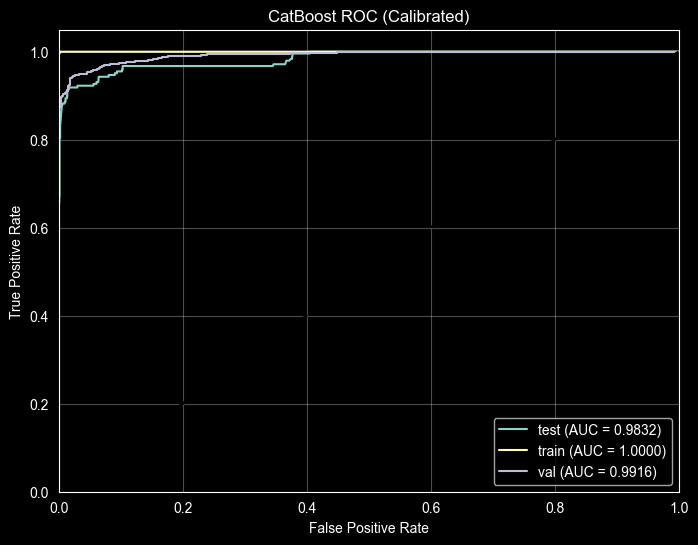

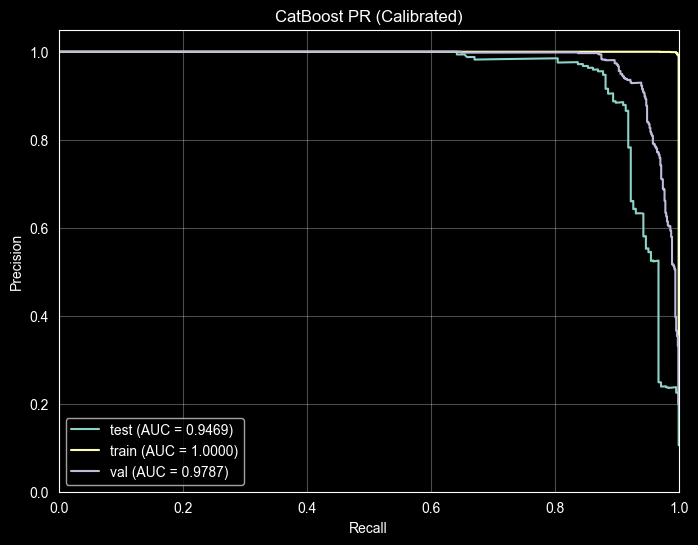

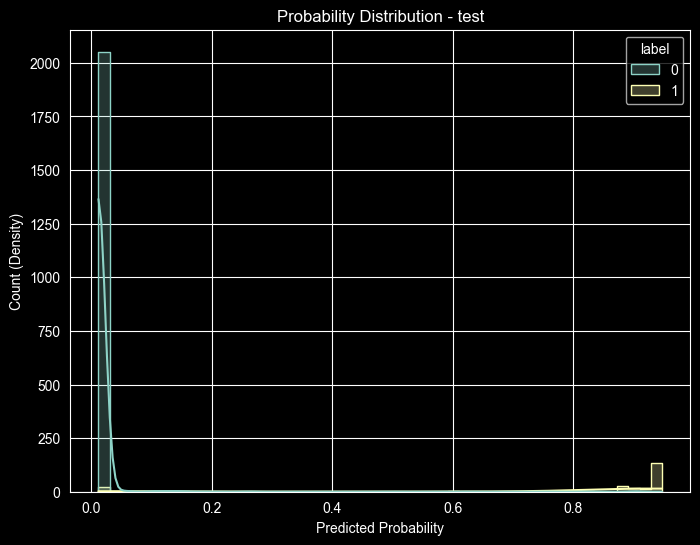

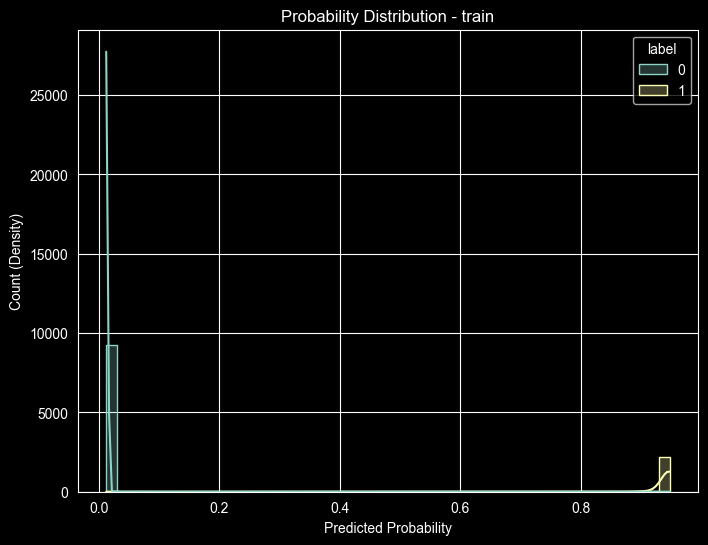

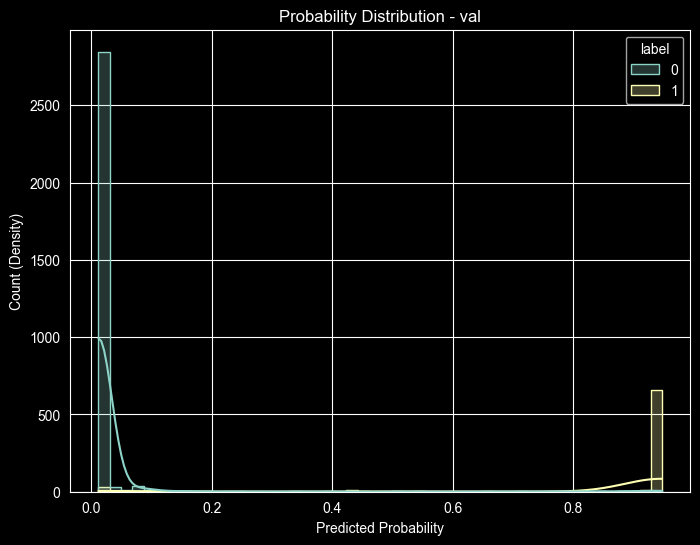

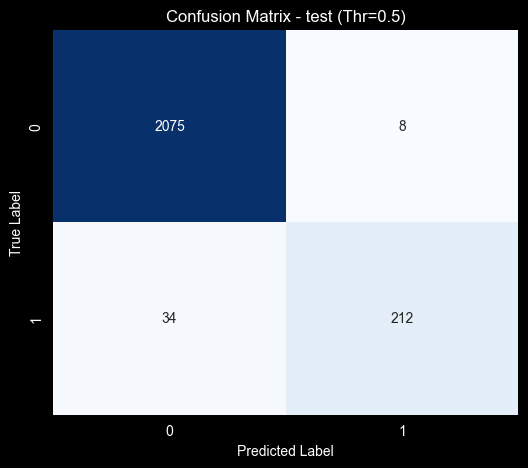

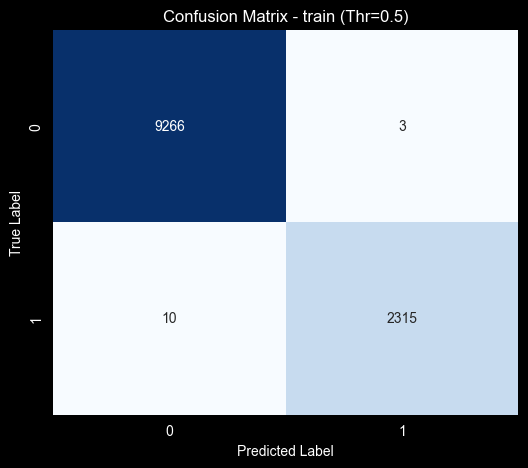

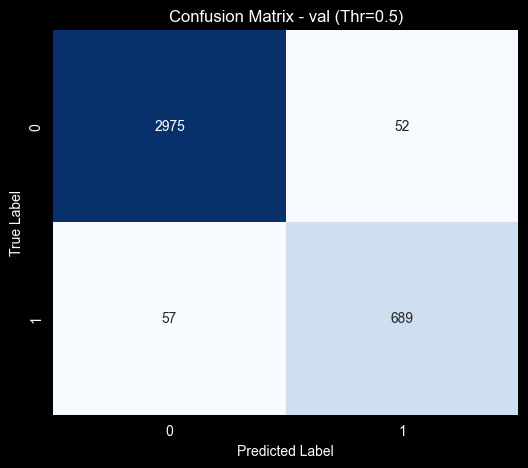

In [5]:
print("\n--- Plots ---")
plot_roc_curves(df_preds, prob_col="p_calib", title="CatBoost ROC (Calibrated)")
plot_pr_curves(df_preds, prob_col="p_calib", title="CatBoost PR (Calibrated)")
plot_probability_distributions(df_preds, prob_col="p_calib")
plot_confusion_matrices(df_preds, prob_col="p_calib", threshold=0.5)